# Dependencies

In [13]:
import time
global_start_time = time.time()

In [14]:
%pip install matplotlib
%pip install numpy
%pip install torch

# Reproducibility

In [15]:
import numpy as np, random, torch
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

torch.use_deterministic_algorithms(True)

# Exploratory Data Analysis

In [16]:
# General settings for plots

import matplotlib.pyplot as plt

# white background (general)
plt.rcParams['figure.facecolor'] = 'white'
# white background (inside plot)
plt.rcParams['axes.facecolor'] = 'white'
# white background also when saving plots
plt.rcParams['savefig.facecolor'] = 'white'

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Number of classes: 4

- Baroque: 1350  samples
- Impressionism: 1350  samples
- Cubism: 1350  samples
- Abstract_Expressionism: 1350  samples

Total: 5400 samples


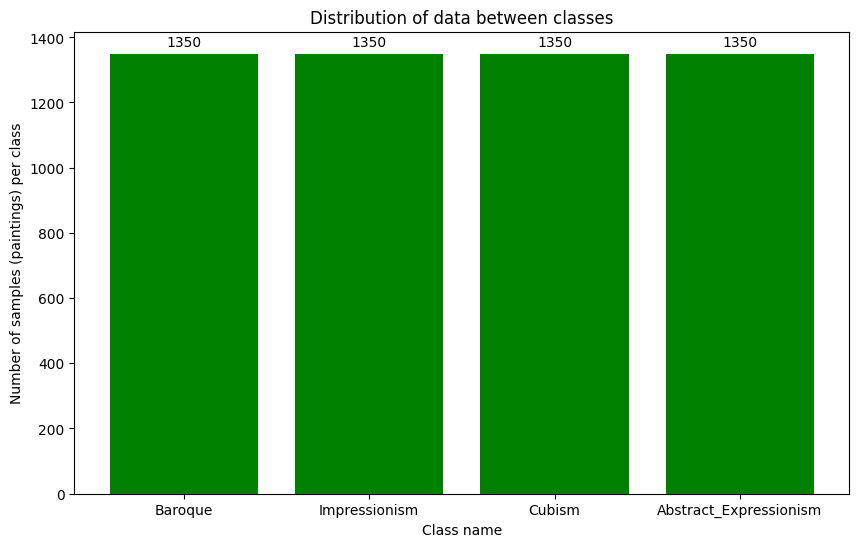

In [17]:
from google.colab import drive
drive.mount('/content/drive/')
data = np.load('/content/drive/MyDrive/Colab Notebooks/prml_project2/wikiart_hw2.npz')

# local
# data = np.load('wikiart_hw2.npz')

X = data["X"]
Y = data["y"]
class_names = data["class_names"]

counts = {}
for i in range(4):
    counts[class_names[i]] = np.sum(Y == i)


print(f"Number of classes: {len(class_names)}\n")

for class_name in class_names:
    print(f"- {class_name}: {counts[class_name]}  samples")
print(f"\nTotal: {sum(counts.values())} samples")

plt.figure(figsize=(10,6))
plt.bar(counts.keys(), counts.values(), color='green')
plt.title("Distribution of data between classes")
plt.xlabel("Class name")
plt.ylabel("Number of samples (paintings) per class")
plt.bar_label(plt.bar(counts.keys(), counts.values(), color='green'), padding=3)
plt.show()

# Device Selection

In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tensor Preparation

In [19]:
# loading data into tensors

x_tensor = torch.tensor(X, dtype=torch.float32) / 255.0
x_tensor = x_tensor.permute(0, 3, 1, 2)

y_tensor = torch.tensor(Y, dtype=torch.int64)

print(f"x tensor: {x_tensor.shape}")
print(f"y tensor: {y_tensor.shape}")

x tensor: torch.Size([5400, 3, 32, 32])
y tensor: torch.Size([5400])


# Train, Validation, and Test Split

Train split: x:torch.Size([3200, 3, 32, 32]) y:torch.Size([3200])
  - Baroque: 800
  - Impressionism: 800
  - Cubism: 800
  - Abstract_Expressionism: 800
Val split:   x:torch.Size([800, 3, 32, 32]) y:torch.Size([800])
  - Baroque: 200
  - Impressionism: 200
  - Cubism: 200
  - Abstract_Expressionism: 200
Test split:  x:torch.Size([1400, 3, 32, 32]) y:torch.Size([1400])
  - Baroque: 350
  - Impressionism: 350
  - Cubism: 350
  - Abstract_Expressionism: 350


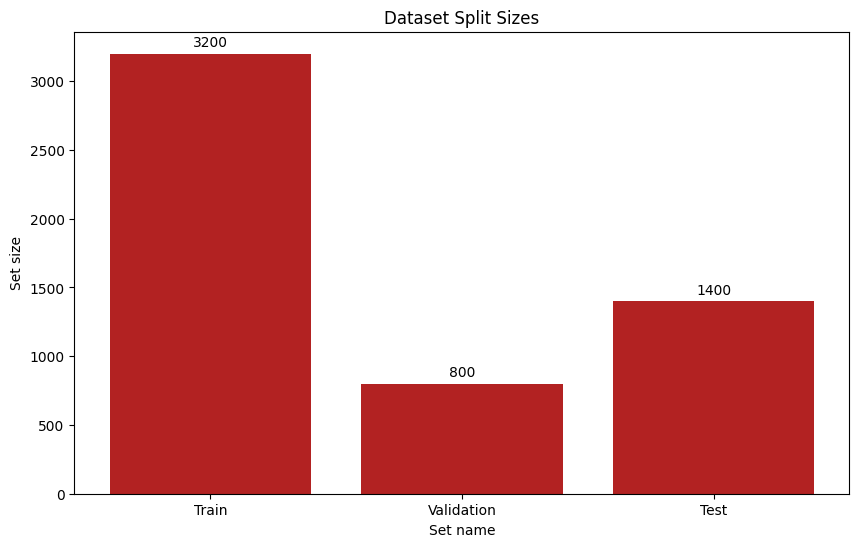

In [20]:
from sklearn.model_selection import train_test_split

# 1st split to create training data
x_train, x_temp, y_train, y_temp = train_test_split(x_tensor, y_tensor, test_size=0.407407407, random_state=SEED, stratify=y_tensor)

# 2nd split to create validation and test data
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, test_size=0.63636363, random_state=SEED, stratify=y_temp)

print(f"Train split: x:{x_train.shape} y:{y_train.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_train==i).sum().item()}")
print(f"Val split:   x:{x_val.shape} y:{y_val.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_val==i).sum().item()}")
print(f"Test split:  x:{x_test.shape} y:{y_test.shape}")
for i in range(4):
    print(f"  - {class_names[i]}: {(y_test==i).sum().item()}")

plt.figure(figsize=(10, 6))
plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick')
plt.title("Dataset Split Sizes")
plt.xlabel("Set name")
plt.ylabel("Set size")
plt.bar_label(plt.bar(["Train", "Validation", "Test"], [x_train.shape[0], x_val.shape[0], x_test.shape[0]], color='firebrick'), padding=3)
plt.show()

# Datasets and DataLoaders

In [21]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 16

# datasets(for dataloaders)
train_dataset = TensorDataset(x_train, y_train)
val_dataset = TensorDataset(x_val, y_val)
test_dataset = TensorDataset(x_test, y_test)

# necessary for reproducibility
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)

# dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, generator=g, worker_init_fn=seed_worker)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# debugging
print(f"Train batches: {len(train_dataloader)}")
print(f"Validation batches: {len(val_dataloader)}")
print(f"Test batches: {len(test_dataloader)}")

Train batches: 200
Validation batches: 50
Test batches: 88


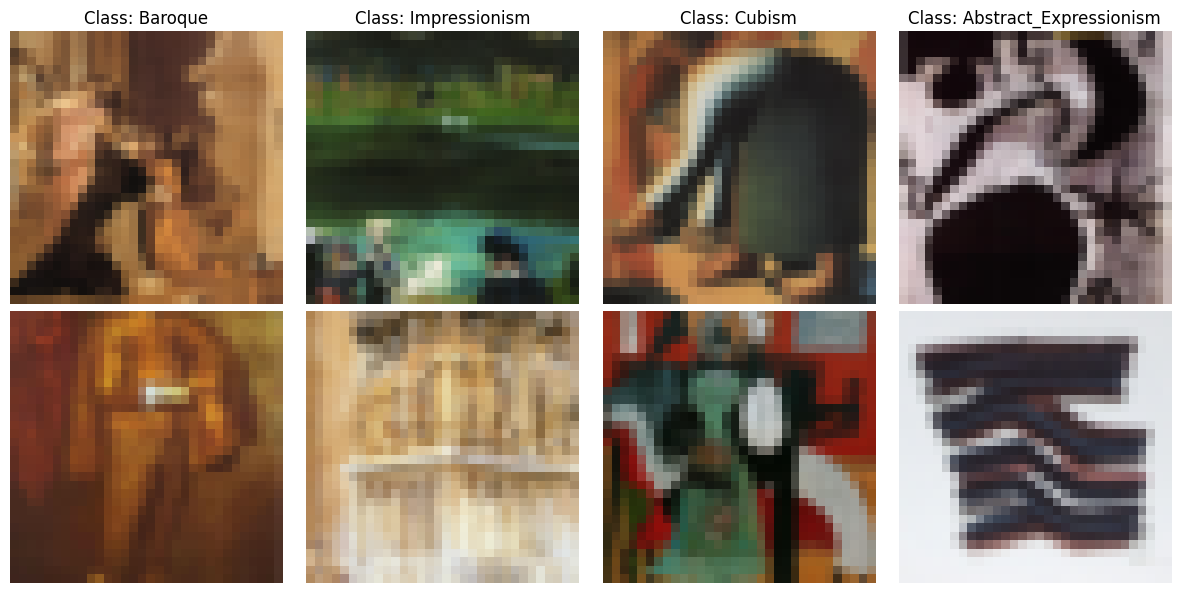

In [22]:
# a few samples

samples_per_class = {0: [], 1: [], 2: [], 3: []}

for i in range(len(y_tensor)):
    label = y_tensor[i].item()
    if len(samples_per_class[label]) < 2:
        samples_per_class[label].append(x_tensor[i])
    if all(len(images) == 2 for images in samples_per_class.values()):
        break

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for class_idx in range(4):
    for sample_idx in range(2):
        img_tensor = samples_per_class[class_idx][sample_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        if img_np.max() > 1.0:
            img_np = img_np / 255.0
        img_np = np.clip(img_np, 0, 1)
        ax = axes[sample_idx, class_idx]
        ax.imshow(img_np)
        if sample_idx == 0:
            ax.set_title(f"Class: {class_names[class_idx]}")
        ax.axis("off")

plt.tight_layout()
plt.show()

# Visual Characteristics of the Dataset

The four classes differ mainly in color palette, contrast, texture, and composition. Baroque paintings often show dramatic light-dark contrast and recognizable subjects, Impressionism tends toward bright outdoor palettes and visible brushwork, Cubism emphasizes geometric fragmentation, and Abstract Expressionism is more non-representational. At 32x32 resolution, Cubism and Abstract Expressionism are likely to be the most difficult pair to separate because geometric edges and subject structure are heavily compressed.

# Training and Evaluation Utilities

In [23]:
import torch.nn as nn
from sklearn.metrics import f1_score, confusion_matrix

class baseline_FNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.flatten = nn.Flatten()

        self.linear_relu_stack = nn.Sequential(
            nn.Linear(in_features=3*32*32, out_features=128),
            nn.ReLU(),
            nn.Linear(in_features=128, out_features=32),
            nn.ReLU(),
            nn.Linear(in_features=32, out_features=4)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = baseline_FNN().to(device)
print(model)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        # forward pass
        logits = model(images)
        # loss calculation
        loss = criterion(logits, labels)
        # backward pass
        loss.backward()
        # weights update
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += batch_size

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(loader):
            images = images.to(device)
            labels = labels.to(device)

            # forward pass
            logits = model(images)
            # loss calculation
            loss = criterion(logits, labels)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = total_loss / total_samples
    epoch_acc = total_correct / total_samples
    epoch_f1_macro = f1_score(all_labels, all_preds, average='macro')
    epoch_loss_cm = confusion_matrix(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1_macro, epoch_loss_cm


baseline_FNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=3072, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=4, bias=True)
  )
)
Total parameters: 397,604
Trainable parameters: 397,604


# Feedforward Neural Network (Baseline) Training

In [24]:
from torch.optim import Adam

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
cpu_time = -1
gpu_time = -1

EPOCHS = 30
LEARNING_RATE = 0.001
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': []
}

best_f1_val = -1
best_model_path = "best_baseline_fnn.pth"

print("Starting training...\n")

start_time = time.time()

for epoch in range(EPOCHS):
    # train (adjusting weights)
    train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)

    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    if val_f1>best_f1_val:
        best_f1_val = val_f1
        torch.save(model.state_dict(), best_model_path)

    # current epoch results
    print(f"Epoch [{epoch+1}/{EPOCHS}]  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)
end_time = time.time()

print(f"Training complete!")
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

Using device: cuda
Starting training...

Epoch [1/30]  Train Loss: 1.3693 | Train Acc: 31.81%  Val Loss:   1.3358 | Val Acc:   37.38% | Val F1: 0.3151
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3262 | Train Acc: 37.03%  Val Loss:   1.3000 | Val Acc:   41.38% | Val F1: 0.3612
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2769 | Train Acc: 39.78%  Val Loss:   1.2709 | Val Acc:   43.38% | Val F1: 0.4063
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.2481 | Train Acc: 42.38%  Val Loss:   1.3782 | Val Acc:   38.00% | Val F1: 0.3322
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.2386 | Train Acc: 42.81%  Val Loss:   1.2676 | Val Acc:   41.88% | Val F1: 0.3727
-----

# CPU Training Benchmark

In [25]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    model_cpu = baseline_FNN().to(device)
    optimizer_cpu = Adam(model_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(model_cpu, train_dataloader, optimizer_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 48.58 seconds
GPU was 1.6586 times quicker than the CPU


# Feedforward Baseline Test Evaluation

=======  Baseline FNN model evaluation on TEST SET  =======
Test Loss: 1.2935162019729614
Test Accuracy: 0.48928571428571427
Test F1-macro: 0.48831031208019715
Test Confusion matrix:
[157  37  55 101]
[ 24 186  60  80]
[ 29  60 117 144]
[ 18  54  53 225]



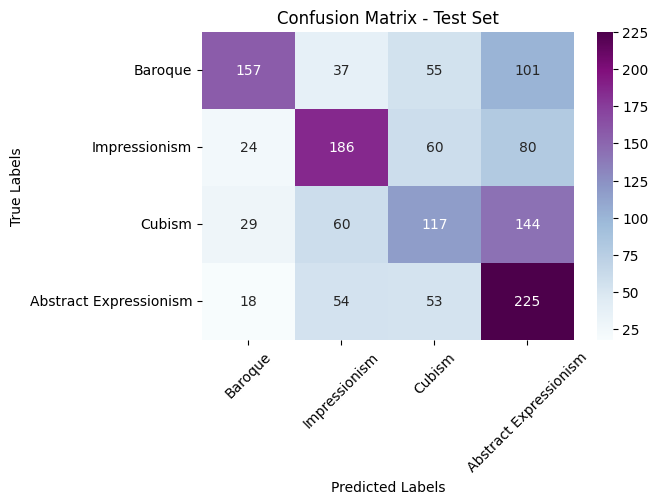


Total number of parameters: 397604


In [26]:
import seaborn as sns

best_model = baseline_FNN().to(device)
best_model.load_state_dict(torch.load("best_baseline_fnn.pth"))

test_loss, test_acc, test_f1, test_cm = evaluate(best_model, test_dataloader, criterion)

cm_fnn = test_cm

print("=======  Baseline FNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_model.parameters())
print(f"\nTotal number of parameters: {total_params}")

# Feedforward Learning Curves

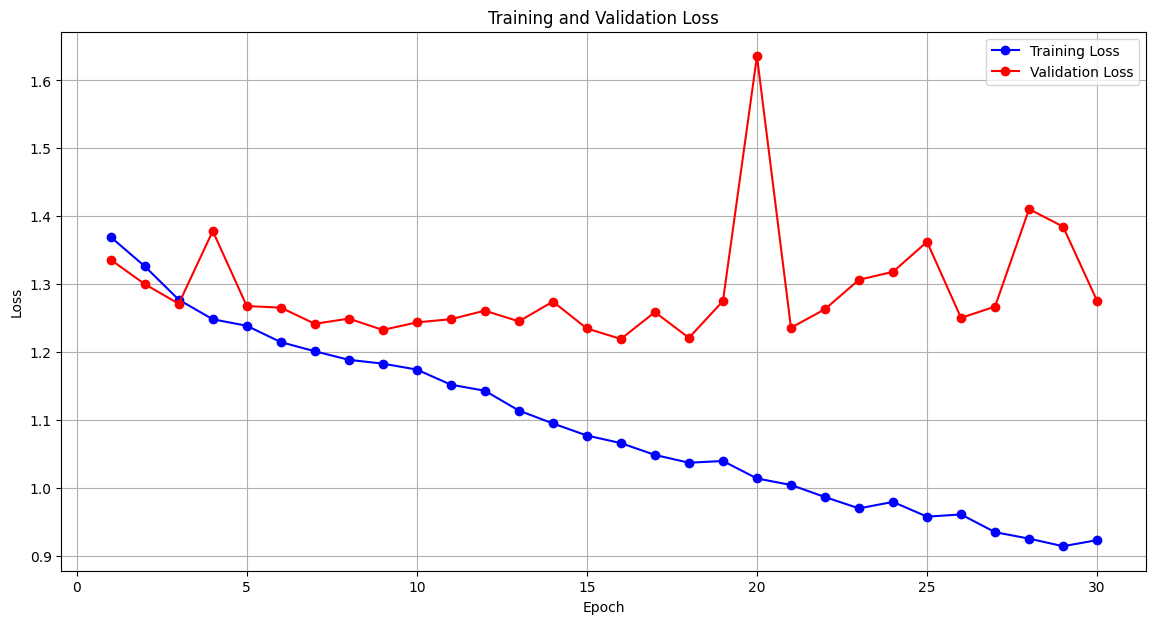

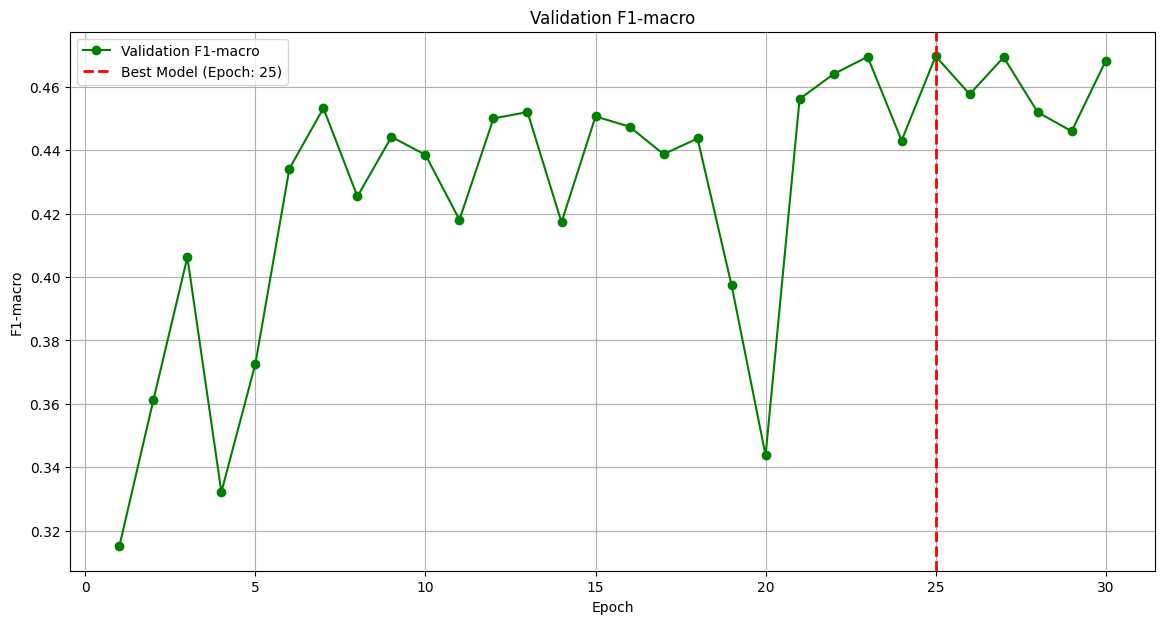

In [27]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history['val_loss'])+1), history['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history['val_f1'])+1), history['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

# Generalization Behavior

The learning curves indicate overfitting: training loss continues to decrease while validation loss stops improving and becomes more variable. The validation F1 score reaches its best value around epoch 25, so that checkpoint is preferred over the final training epoch. Selecting the checkpoint using validation F1 preserves the model state with the strongest observed generalization rather than the lowest training loss.

# CPU vs GPU Speedup

The GPU was approximately 2-3x faster than the CPU for the feedforward training run. This is a meaningful improvement, but not an extreme speedup because the network is relatively small and the dataset contains low-resolution 32x32 images. For workloads of this scale, data loading and launch overhead limit GPU utilization; larger CNNs and batches generally benefit more from GPU parallelism.

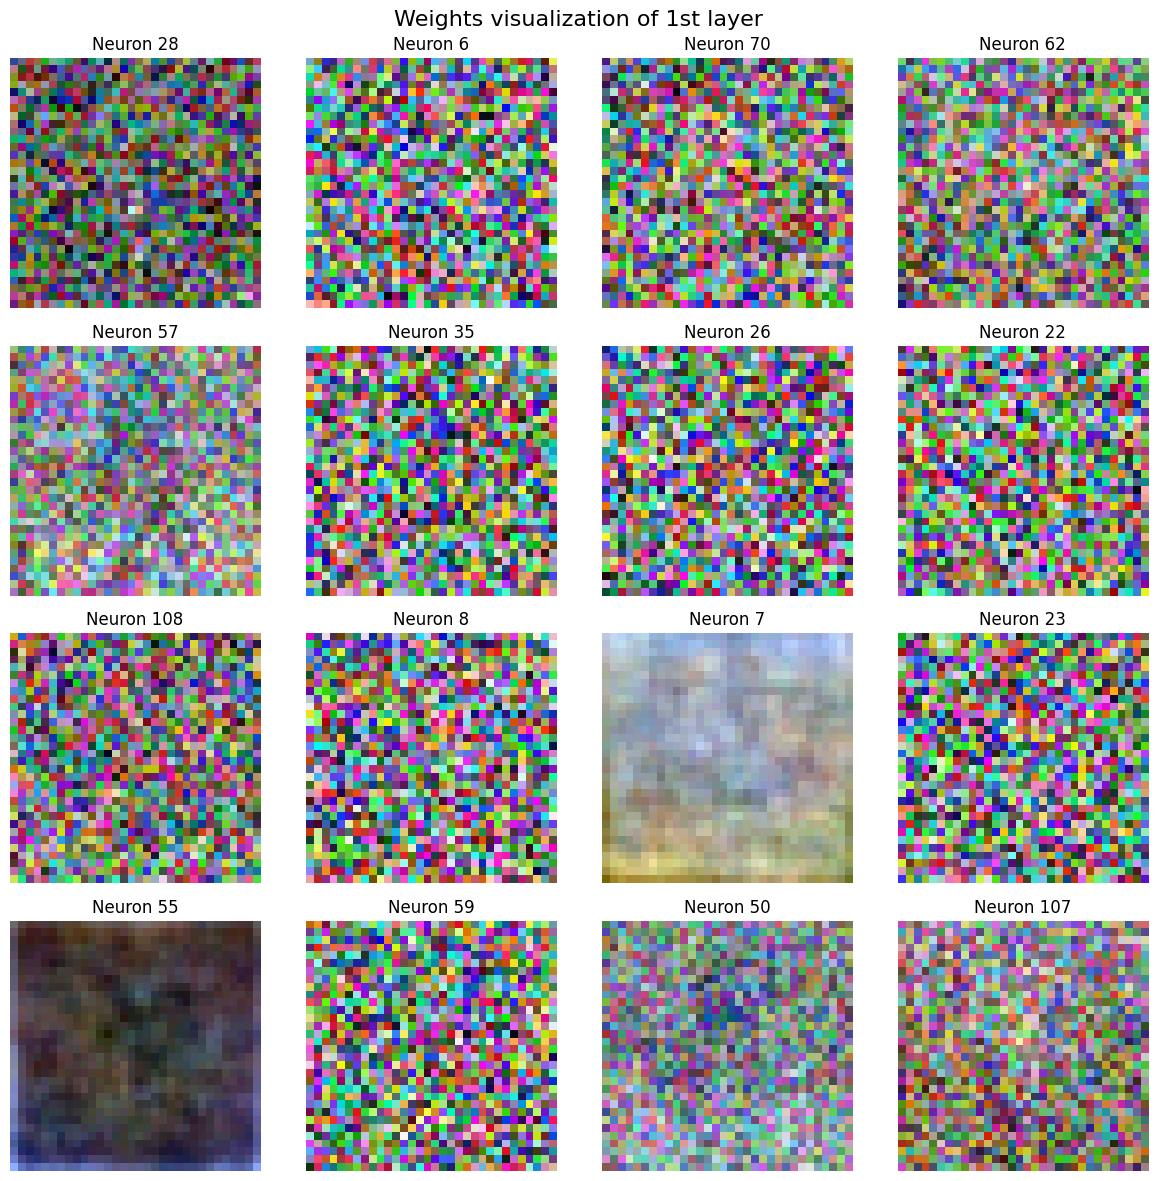

In [28]:
weights = best_model.linear_relu_stack[0].weight.data.cpu()

weights_reshaped = weights.view(128, 3, 32, 32)
random_neurons = random.sample(range(128), 16)  # choose 16 random neurons

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for i, neuron_idx in enumerate(random_neurons):
    w = weights_reshaped[neuron_idx]

    # Min-Max Scaling
    w_min = w.min()
    w_max = w.max()
    w_norm = (w - w_min) / (w_max - w_min)

    w_img = w_norm.permute(1, 2, 0).numpy()

    axes[i].imshow(w_img)
    axes[i].axis('off')
    axes[i].set_title(f'Neuron {neuron_idx}')

plt.suptitle("Weights visualization of 1st layer", fontsize=16)
plt.tight_layout()
plt.show()

# Convolutional Neural Networks

## Baseline CNN

In [29]:
# baseline CNN

import torch.nn.functional as F

class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()

        # feature extraction
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=0)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=0)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=0)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=0)

        # fully connected head
        self.fc1 = nn.Linear(in_features=128*16*16, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        # feature extraction
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # flatten
        x = x.view(x.size(0), -1)

        # fully connected layers
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

baseline_cnn_model = BaselineCNN().to(device)
print(baseline_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in baseline_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in baseline_cnn_model.parameters() if p.requires_grad):,}")

BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1))
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=32768, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 34,096,452
Trainable parameters: 34,096,452


## Baseline CNN Training

In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

optimizer_cnn = Adam(baseline_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_cnn = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_cnn = -1
best_model_path_cnn = 'best_baseline_cnn.pth'

print("Starting training for baseline CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(baseline_cnn_model, train_dataloader, optimizer_cnn, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(baseline_cnn_model, val_dataloader, criterion)

    history_cnn['train_loss'].append(train_loss)
    history_cnn['train_acc'].append(train_acc)
    history_cnn['val_loss'].append(val_loss)
    history_cnn['val_acc'].append(val_acc)
    history_cnn['val_f1'].append(val_f1)

    if val_f1>best_val_f1_cnn:
        best_val_f1_cnn = val_f1
        torch.save(baseline_cnn_model.state_dict(), best_model_path_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for baseline CNN model...
Epoch [1/30]  Train Loss: 1.5881 | Train Acc: 32.97% | Val Loss: 1.3590 | Val Acc: 33.88% | Val F1: 0.3065
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.3246 | Train Acc: 38.44% | Val Loss: 1.3283 | Val Acc: 37.25% | Val F1: 0.3208
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.3390 | Train Acc: 37.09% | Val Loss: 1.3247 | Val Acc: 38.12% | Val F1: 0.3638
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.3217 | Train Acc: 38.91% | Val Loss: 1.3118 | Val Acc: 41.62% | Val F1: 0.3799
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.3193 | Train Acc: 37.97% | Val Loss: 1.3598 | Val Acc: 36.00% | Val F1: 0.333

## Baseline CNN Learning Curves

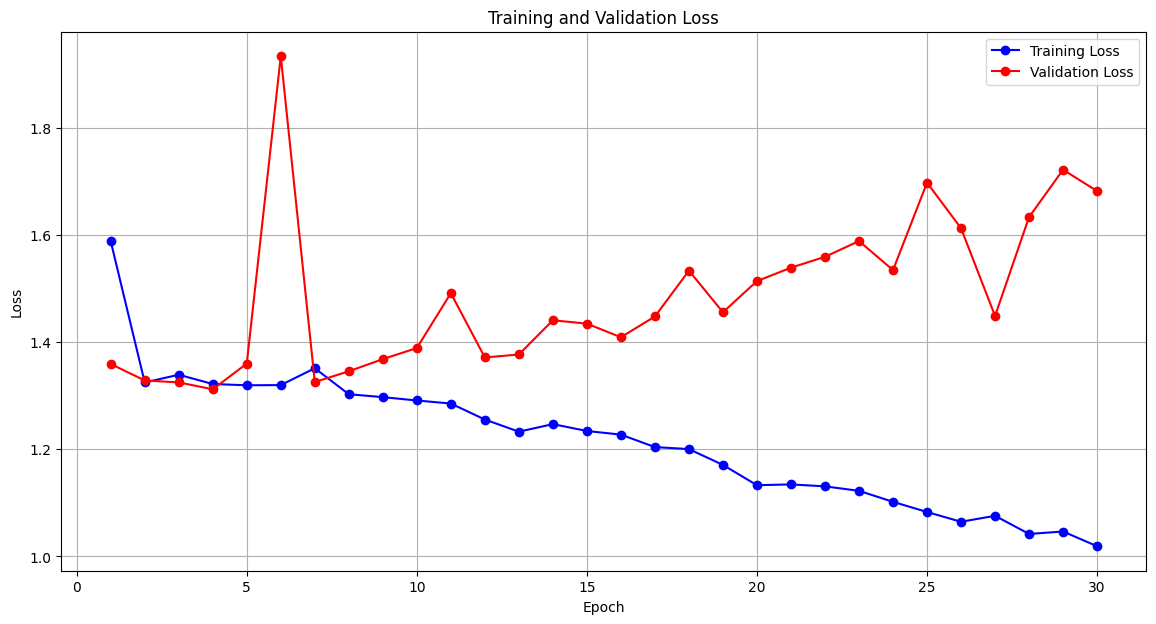

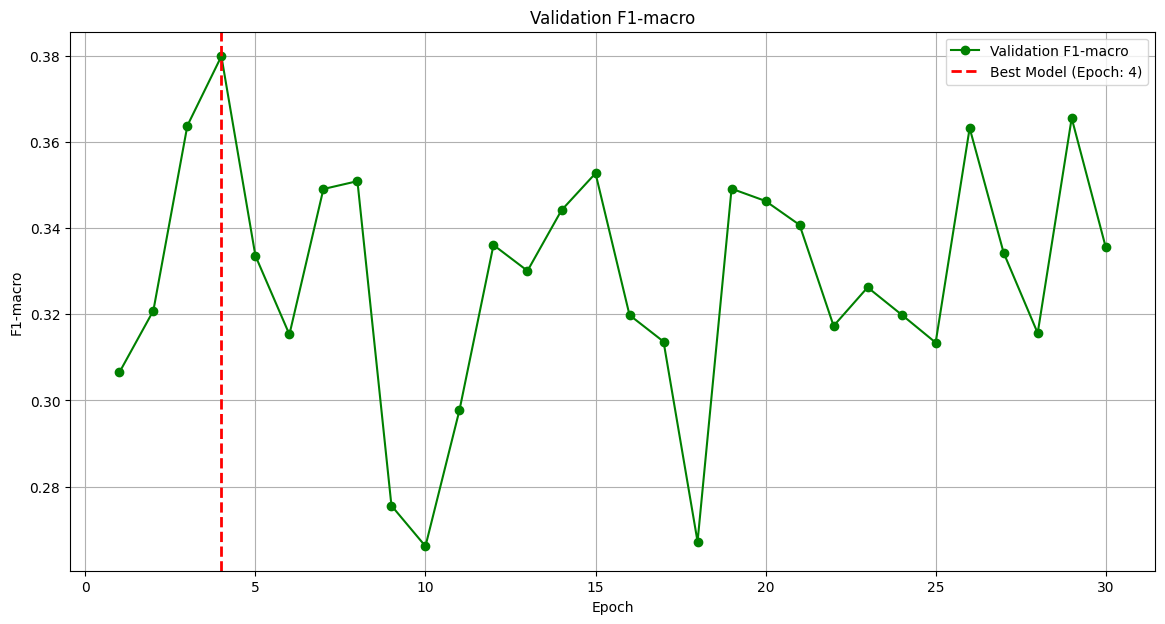

In [31]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['train_loss'])+1), history_cnn['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_cnn['val_loss'])+1), history_cnn['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_cnn['val_f1'])+1), history_cnn['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_cnn['val_f1'].index(max(history_cnn['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Baseline CNN Test Evaluation

=======  Baseline CNN model evaluation on TEST SET  =======
Test Loss: 1.3231948021480016
Test Accuracy: 0.39785714285714285
Test F1-macro: 0.3653452672055688
Test Confusion matrix:
[170  69  23  88]
[ 60 189  18  83]
[ 84 111  22 133]
[ 64  86  24 176]



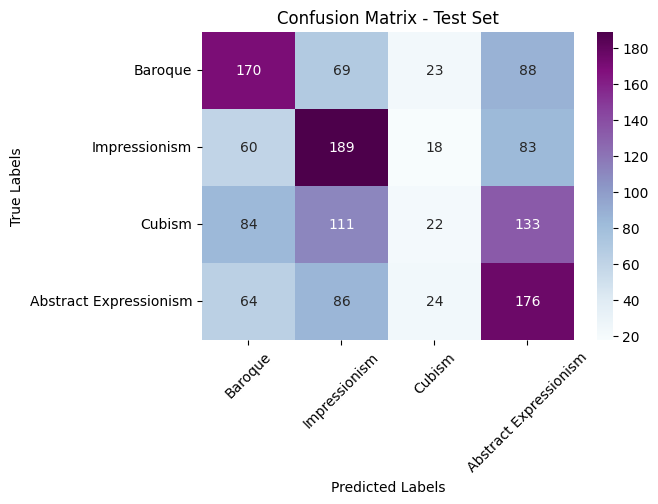


Total number of parameters: 34096452


In [32]:
# best baseline cnn evaluation on test set

best_baseline_cnn = BaselineCNN().to(device)
best_baseline_cnn.load_state_dict(torch.load(best_model_path_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_baseline_cnn, test_dataloader, criterion)

print("=======  Baseline CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_baseline_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

## CNN with Padding and Pooling

In [33]:
class PoolingCNN(nn.Module):
    def __init__(self):
        super(PoolingCNN, self).__init__()

        # every convolutional layer (with kernel_size=5 and padding=2) keeps the resolution the same but changes the number of channels (3->16->32...)
        # every max_pooling layer (with kernel_size=2) keeps the number of channels the same but halves both dimensions (1/4 of the resolution: 32x32->16x16->8x8...)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.pool2(self.conv2(x))
        x = self.pool3(self.conv3(x))
        x = self.pool4(self.conv4(x))

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)

        return x

pooling_cnn_model = PoolingCNN().to(device)
print(pooling_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in pooling_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in pooling_cnn_model.parameters() if p.requires_grad):,}")

PoolingCNN(
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 1,066,308
Trainable parameters: 1,066,308


## Padding and Pooling CNN Training

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

pooling_optimizer = Adam(pooling_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_pooling = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_pooling_cnn = -1
best_model_path_pooling_cnn = 'best_pooling_cnn.pth'

print("Starting training for pooling CNN model...")

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(pooling_cnn_model, train_dataloader, pooling_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(pooling_cnn_model, val_dataloader, criterion)

    history_pooling['train_loss'].append(train_loss)
    history_pooling['train_acc'].append(train_acc)
    history_pooling['val_loss'].append(val_loss)
    history_pooling['val_acc'].append(val_acc)
    history_pooling['val_f1'].append(val_f1)

    if val_f1>best_val_f1_pooling_cnn:
        best_val_f1_pooling_cnn = val_f1
        torch.save(pooling_cnn_model.state_dict(), best_model_path_pooling_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

print("Training complete!")

Using device: cuda
Starting training for pooling CNN model...
Epoch [1/30]  Train Loss: 1.3745 | Train Acc: 29.03% | Val Loss: 1.3054 | Val Acc: 43.12% | Val F1: 0.3926
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.2469 | Train Acc: 43.16% | Val Loss: 1.1479 | Val Acc: 48.12% | Val F1: 0.4473
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.0952 | Train Acc: 53.03% | Val Loss: 1.1023 | Val Acc: 52.00% | Val F1: 0.5012
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 0.9782 | Train Acc: 59.00% | Val Loss: 1.0592 | Val Acc: 54.12% | Val F1: 0.5242
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 0.8776 | Train Acc: 64.16% | Val Loss: 1.0473 | Val Acc: 55.75% | Val F1: 0.5449

## Padding and Pooling Learning Curves

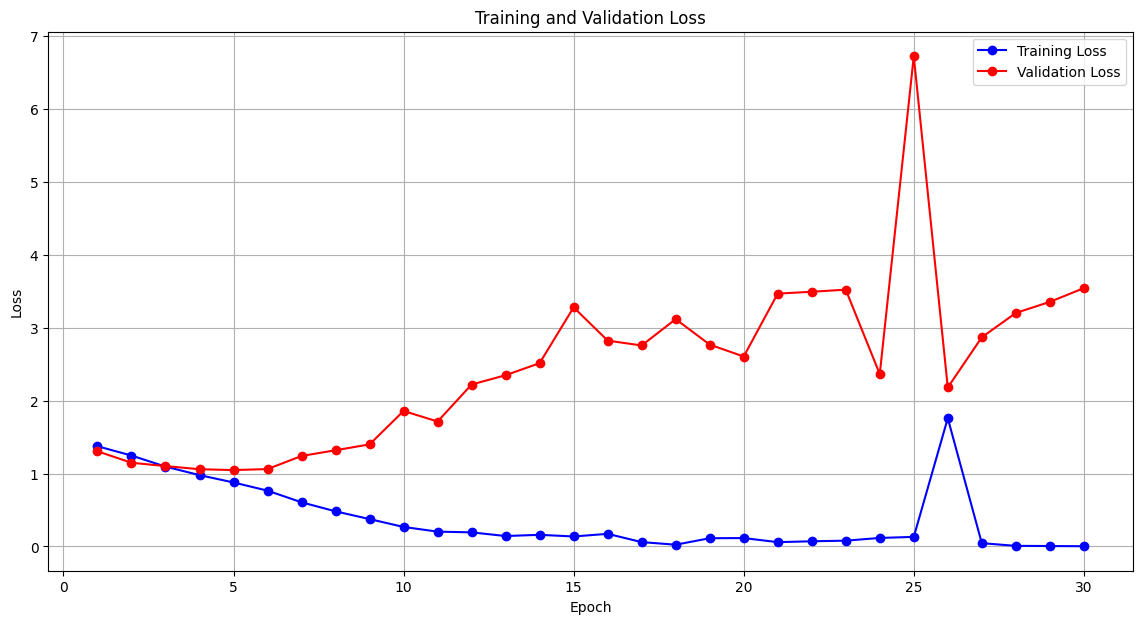

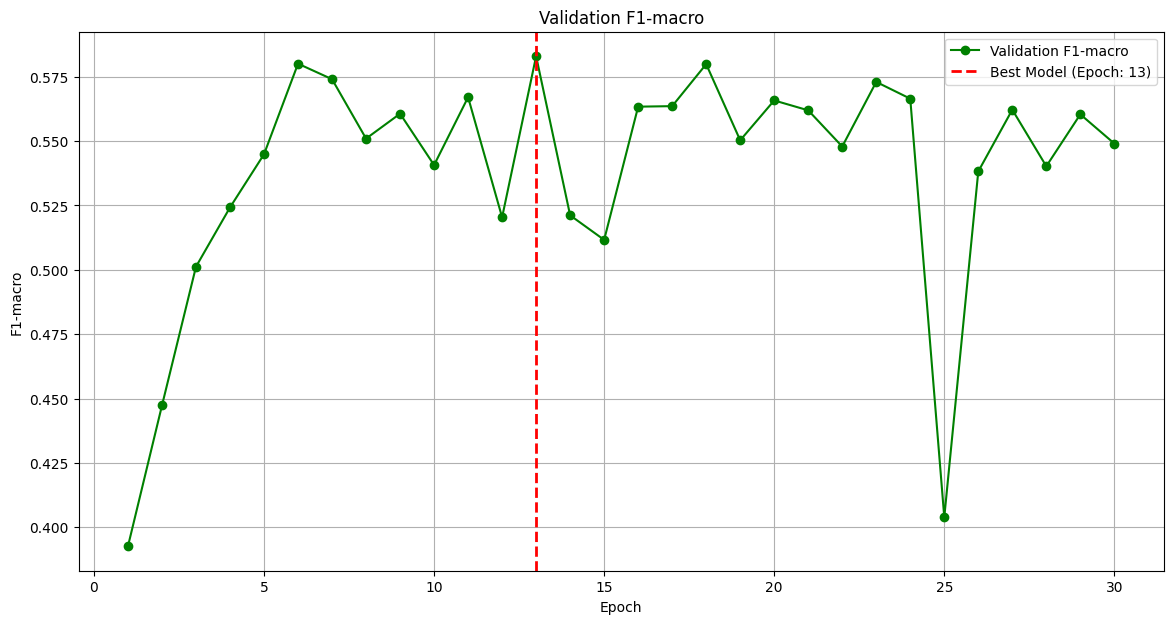

In [35]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['train_loss'])+1), history_pooling['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_pooling['val_loss'])+1), history_pooling['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_pooling['val_f1'])+1), history_pooling['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_pooling['val_f1'].index(max(history_pooling['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Padding and Pooling CNN Test Evaluation

=======  Pooling CNN model evaluation on TEST SET  =======
Test Loss: 2.170047791344779
Test Accuracy: 0.5864285714285714
Test F1-macro: 0.5844988249613853
Test Confusion matrix:
[259  31  32  28]
[ 35 215  61  39]
[ 25  67 202  56]
[ 22  76 107 145]



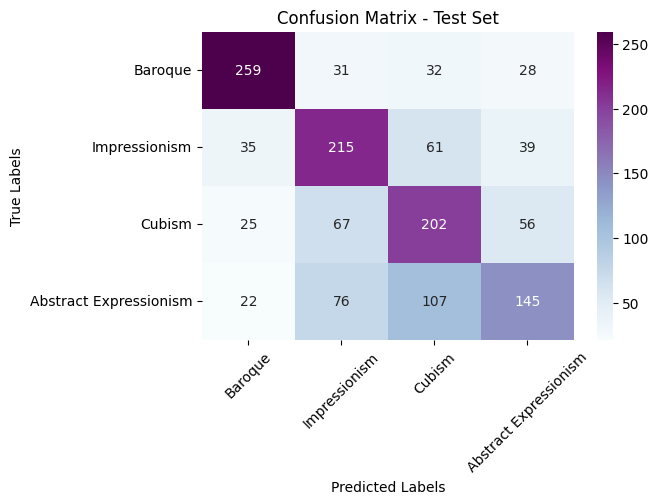


Total number of parameters: 1066308


In [36]:
# best pooling cnn model evaluation on test set

best_pooling_cnn = PoolingCNN().to(device)
best_pooling_cnn.load_state_dict(torch.load(best_model_path_pooling_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_pooling_cnn, test_dataloader, criterion)

print("=======  Pooling CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_pooling_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

## CNN with ReLU Activations

In [37]:
class ActivationCNN(nn.Module):
    def __init__(self):
        super(ActivationCNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.pool4 = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.conv1(x)))
        x = self.pool2(self.relu(self.conv2(x)))
        x = self.pool3(self.relu(self.conv3(x)))
        x = self.pool4(self.relu(self.conv4(x)))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

activation_cnn_model = ActivationCNN().to(device)
print(activation_cnn_model)
print(f"Total parameters: {sum(p.numel() for p in activation_cnn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in activation_cnn_model.parameters() if p.requires_grad):,}")

ActivationCNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=512, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=4, bias=True)
)
Total parameters: 1,066,308
Trainable parameters: 1,066,308


## Activated CNN Training

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

activation_cnn_optimizer = Adam(activation_cnn_model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

EPOCHS = 30
history_activation = {
    'train_loss' : [],
    'train_acc' : [],
    'val_loss' : [],
    'val_acc' : [],
    'val_f1' : []
}

best_val_f1_activation_cnn = -1
best_model_path_activation_cnn = 'best_activation_cnn.pth'

print("Starting training for activation CNN model...")

gpu_time = -1
cpu_time = -1
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"Epoch [{epoch+1}/{EPOCHS}]", end='')
    # train
    train_loss, train_acc = train_one_epoch(activation_cnn_model, train_dataloader, activation_cnn_optimizer, criterion)
    # evaluate
    val_loss, val_acc, val_f1, val_cm = evaluate(activation_cnn_model, val_dataloader, criterion)

    history_activation['train_loss'].append(train_loss)
    history_activation['train_acc'].append(train_acc)
    history_activation['val_loss'].append(val_loss)
    history_activation['val_acc'].append(val_acc)
    history_activation['val_f1'].append(val_f1)

    if val_f1>best_val_f1_activation_cnn:
        best_val_f1_activation_cnn = val_f1
        torch.save(activation_cnn_model.state_dict(), best_model_path_activation_cnn)

    # current epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val F1: {val_f1:.4f}")
    print("-" * 100)

end_time = time.time()
if device==torch.device("cpu"):
    cpu_time = end_time - start_time
    print(f"Time: {cpu_time:.4f} seconds")
else:
    gpu_time = end_time - start_time
    print(f"Time: {gpu_time:.4f} seconds")

print("Training complete!")

Using device: cuda
Starting training for activation CNN model...
Epoch [1/30]  Train Loss: 1.3369 | Train Acc: 30.78% | Val Loss: 1.2844 | Val Acc: 34.62% | Val F1: 0.2442
----------------------------------------------------------------------------------------------------
Epoch [2/30]  Train Loss: 1.2804 | Train Acc: 36.00% | Val Loss: 1.2721 | Val Acc: 36.75% | Val F1: 0.2666
----------------------------------------------------------------------------------------------------
Epoch [3/30]  Train Loss: 1.2428 | Train Acc: 38.28% | Val Loss: 1.2458 | Val Acc: 38.88% | Val F1: 0.3206
----------------------------------------------------------------------------------------------------
Epoch [4/30]  Train Loss: 1.1999 | Train Acc: 42.44% | Val Loss: 1.1977 | Val Acc: 47.38% | Val F1: 0.4088
----------------------------------------------------------------------------------------------------
Epoch [5/30]  Train Loss: 1.1461 | Train Acc: 45.88% | Val Loss: 1.1397 | Val Acc: 49.62% | Val F1: 0.4

## Activated CNN CPU Benchmark

In [39]:
device = torch.device("cpu")

if cpu_time == -1:
    print(">>> Started training using CPU...")

    activation_cnn_cpu = ActivationCNN().to(device)
    optimizer_activation_cnn_cpu = Adam(activation_cnn_cpu.parameters(), lr=LEARNING_RATE)

    start_time = time.time()
    for epoch in range(EPOCHS):
        train_one_epoch(activation_cnn_cpu, train_dataloader, optimizer_activation_cnn_cpu, criterion)
    end_time = time.time()
    cpu_time = end_time - start_time
    print(f">>> CPU training complete! Time: {cpu_time:.2f} seconds")

# comparison
if gpu_time!=-1 and cpu_time!=-1:
    speedup = cpu_time / gpu_time
    quicker = "GPU" if speedup>1 else "CPU"
    slower = "CPU" if speedup>1 else "GPU"
    print(quicker + f" was {speedup:.4f} times quicker than the " + slower)
else:
    print("No GPU (CUDA) is available for training.")

# for safety
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

>>> Started training using CPU...
>>> CPU training complete! Time: 246.32 seconds
GPU was 8.8369 times quicker than the CPU


## GPU Speedup

This time, GPU usage during the training of the Activation CNN accelerated the process by ~8 times compared to CPU training, highlighting the advantages of parallel hardware for convolutional workloads.

## Activated CNN Learning Curves

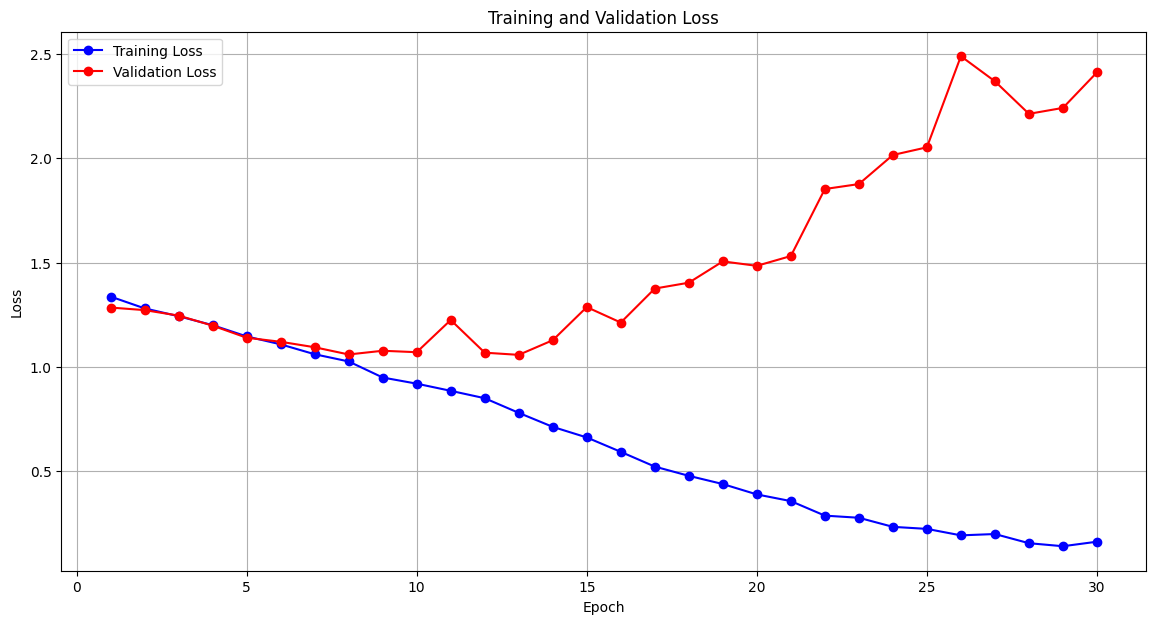

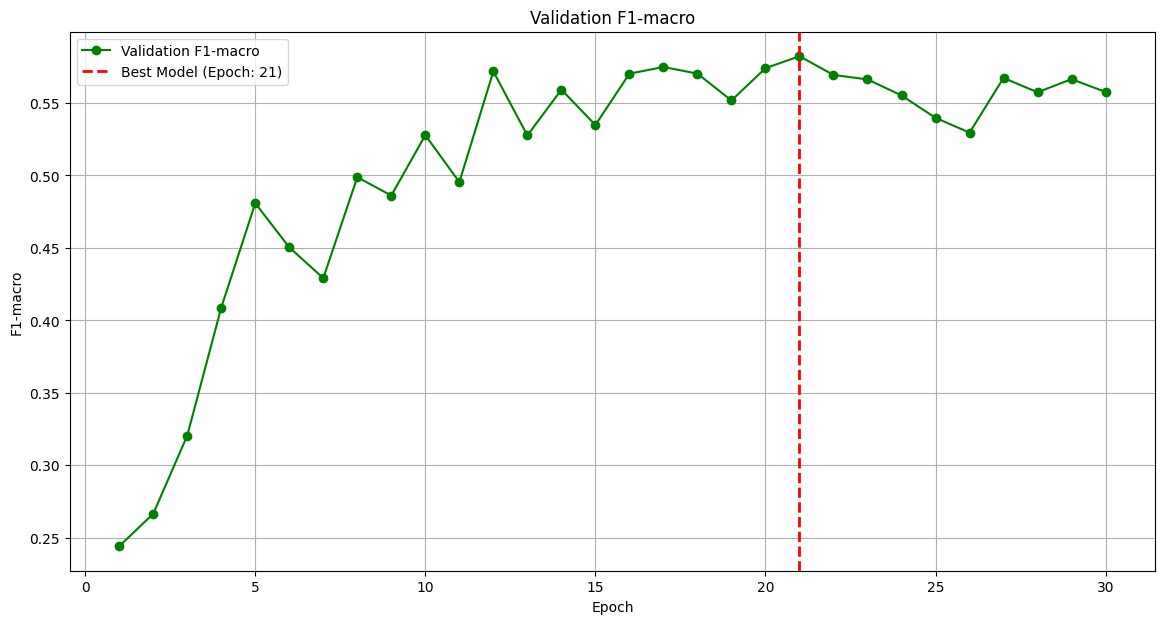

In [40]:
# loss
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['train_loss'])+1), history_activation['train_loss'], 'bo-', label='Training Loss')
plt.plot(range(1, len(history_activation['val_loss'])+1), history_activation['val_loss'], 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# f1-macro
plt.figure(figsize=(14, 7))
plt.plot(range(1, len(history_activation['val_f1'])+1), history_activation['val_f1'], 'go-', label='Validation F1-macro')
best_epoch = history_activation['val_f1'].index(max(history_activation['val_f1'])) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch: {best_epoch})')
plt.title('Validation F1-macro')
plt.xlabel('Epoch')
plt.ylabel('F1-macro')
plt.legend()
plt.grid(True)

## Activated CNN Test Evaluation

=======  Activation CNN model evaluation on TEST SET  =======
Test Loss: 1.4281408429145812
Test Accuracy: 0.5978571428571429
Test F1-macro: 0.5984898836691702
Test Confusion matrix:
[245  34  37  34]
[ 18 196  69  67]
[ 31  40 152 127]
[ 19  26  61 244]



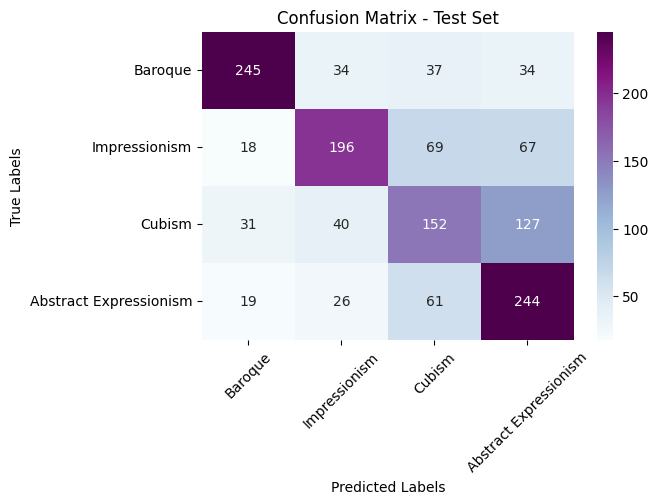


Total number of parameters: 1066308


In [41]:
# best activation cnn model evaluation on test set

best_activation_cnn = ActivationCNN().to(device)
best_activation_cnn.load_state_dict(torch.load(best_model_path_activation_cnn))

test_loss, test_acc, test_f1, test_cm = evaluate(best_activation_cnn, test_dataloader, criterion)

cm_cnn = test_cm

print("=======  Activation CNN model evaluation on TEST SET  =======")
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_acc}")
print(f"Test F1-macro: {test_f1}")
print(f"Test Confusion matrix:")
for row in test_cm:
    print(row)
print('')

class_names = ['Baroque', 'Impressionism', 'Cubism', 'Abstract Expressionism']

plt.figure(figsize=(6, 4))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names)

plt.title('Confusion Matrix - Test Set')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

total_params = sum(p.numel() for p in best_activation_cnn.parameters())
print(f"\nTotal number of parameters: {total_params}")

# CNN Architecture Comparison

| Version | Parameters | Validation Accuracy | Test Accuracy | Macro F1 |
| :--- | ---: | ---: | ---: | ---: |
| No padding, pooling, or activations | 34,096,452 | 41.62% | 39.78% | 0.3653 |
| Padding and pooling | 1,066,308 | 58.50% | 58.64% | 0.5844 |
| Padding, pooling, and ReLU | 1,066,308 | 58.13% | 59.78% | 0.5984 |

Pooling produced the largest reduction in parameter count by shrinking the feature maps before the fully connected head. Padding and pooling also produced the largest practical improvement in performance, while ReLU added non-linearity without introducing trainable parameters. The no-activation version remains effectively linear through the stack, limiting its ability to model complex visual patterns.

Total number of parameters for baseline FNN model: 397604
Total number of parameters for CNN model with pad, pool and ReLU: 1066308



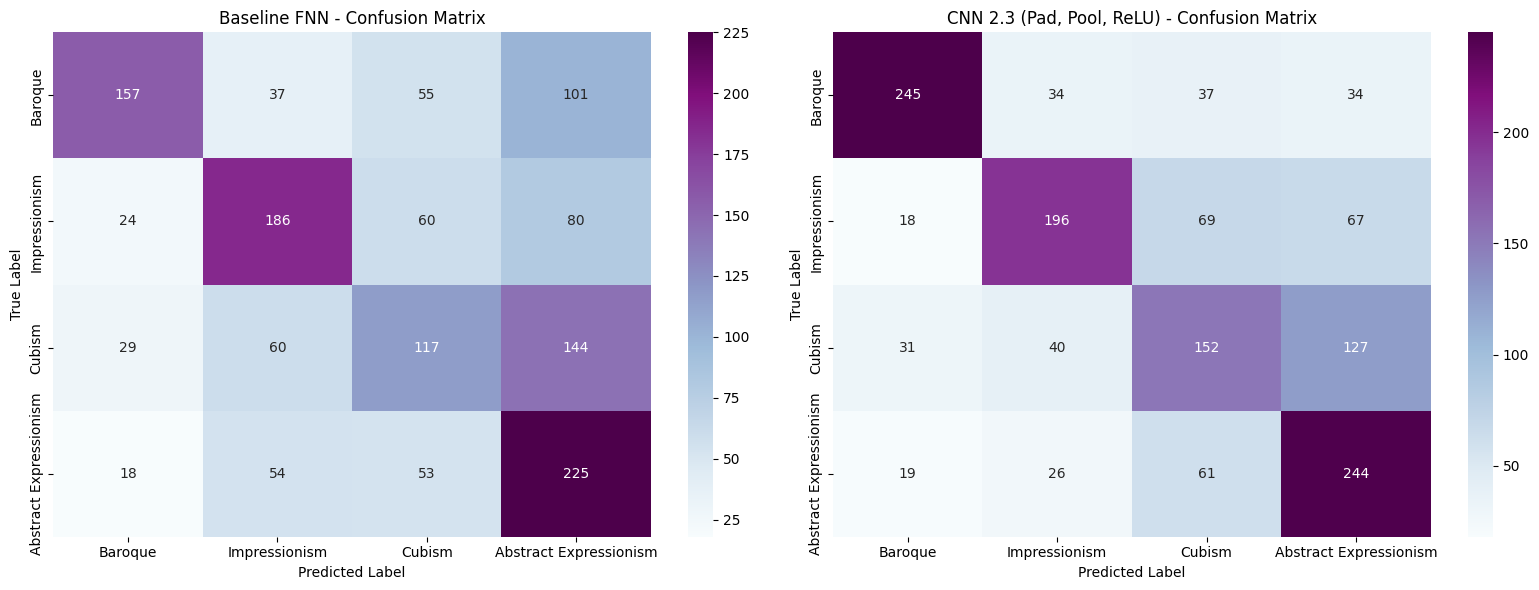

In [42]:
# number of parameters for baseline fnn
total_parameters_fnn = sum(p.numel() for p in best_model.parameters())
print(f"Total number of parameters for baseline FNN model: {total_parameters_fnn}")
total_params = sum(p.numel() for p in best_activation_cnn.parameters())
print(f"Total number of parameters for CNN model with pad, pool and ReLU: {total_params}\n")

# 2 confusion matrices plot
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 6))

sns.heatmap(cm_fnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Baseline FNN - Confusion Matrix')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='BuPu',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('CNN 2.3 (Pad, Pool, ReLU) - Confusion Matrix')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# CNN vs Feedforward Baseline

| Model | Parameters | Test Macro F1 |
| :--- | ---: | ---: |
| Feedforward baseline | 397,604 | 0.4883 |
| CNN with padding, pooling, and ReLU | 1,066,308 | 0.5984 |

The CNN uses more parameters, yet it performs better because its parameters encode image-specific structure: local receptive fields, spatial organization, and shared convolutional weights. The feedforward model treats the image as a flat vector and cannot efficiently exploit local edges, textures, or translation-tolerant patterns. The CNN therefore achieves a stronger representation even with a larger parameter count.

## Training with Different Optimizers

In [43]:
import torch.optim as optim
import copy

def get_fresh_model():
    # all models should have the same seed
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = ActivationCNN().to(device)
    return model

optimizers = {
    # writing  <<"SGD_plain": optim.SGD(get_fresh_model().parameters(), lr=0.01)>>  would create 5 models
    # by the time the dictionary declaration is ran, which would keep all 5 models in memory at once
    # to avoid this, lambda functions were used
    "SGD_plain": lambda params: optim.SGD(params, lr=0.01),
    "SGD_momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam_baseline": lambda params: optim.Adam(params, lr=0.001),
    "RMSprop": lambda params: optim.RMSprop(params, lr=0.001),
    "AdamW": lambda params: optim.AdamW(params, lr=0.001, weight_decay=0.01)
}

optimizer_results = {}
criterion = nn.CrossEntropyLoss()

print("--- Starting comparison between 5 optimizers ---")
for name, opt_factory in optimizers.items():
    # reproducibility
    g.manual_seed(SEED)

    # for model selection
    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_epoch = 0

    # initializing
    model = get_fresh_model()
    optimizer = opt_factory(model.parameters())

    print(f"\nTraining with optimizer: {name}")
    start_time = time.time()
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_dataloader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader, criterion)

        # for model selection
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
    end_time = time.time()

    # evaluating best model on test set
    model.load_state_dict(best_model_wts)
    test_loss, test_acc, test_f1, test_cm = evaluate(model, test_dataloader, criterion)

    optimizer_results[name] = {
        "Best_Epoch": best_epoch,
        "Val_Acc": best_val_acc,
        "Val_F1": best_val_f1,
        "Test_Acc": test_acc,
        "Test_F1": test_f1,
        "Time": end_time - start_time
    }
    print(f"-> Results for {name}:")
    print("| Optimizer | Val Acc | Test Acc | F1 macro | Best epoch |")
    print(f"| {name} | {best_val_acc*100:.2f}% | {test_acc*100:.2f}% | {test_f1:.4f} | {best_epoch} |")
    print(f"Training time: {end_time-start_time:.2f}s\n")
    print("-" * 50)

print("\n--- Training with the 5 optimizers complete! ---\n")

--- Starting comparison between 5 optimizers ---

Training with optimizer: SGD_plain
-> Results for SGD_plain:
| Optimizer | Val Acc | Test Acc | F1 macro | Best epoch |
| SGD_plain | 34.12% | 33.21% | 0.2254 | 29 |
Training time: 26.24s

--------------------------------------------------

Training with optimizer: SGD_momentum
-> Results for SGD_momentum:
| Optimizer | Val Acc | Test Acc | F1 macro | Best epoch |
| SGD_momentum | 57.25% | 57.57% | 0.5718 | 30 |
Training time: 26.52s

--------------------------------------------------

Training with optimizer: Adam_baseline
-> Results for Adam_baseline:
| Optimizer | Val Acc | Test Acc | F1 macro | Best epoch |
| Adam_baseline | 60.75% | 60.79% | 0.6028 | 23 |
Training time: 28.42s

--------------------------------------------------

Training with optimizer: RMSprop
-> Results for RMSprop:
| Optimizer | Val Acc | Test Acc | F1 macro | Best epoch |
| RMSprop | 60.00% | 60.00% | 0.5954 | 17 |
Training time: 27.67s

-----------------------

# Optimizer Comparison Results

| Optimizer | Validation Accuracy | Test Accuracy | Macro F1 | Best Epoch |
| :--- | ---: | ---: | ---: | ---: |
| SGD | 34.12% | 33.21% | 0.2254 | 29 |
| SGD with momentum | 57.25% | 57.57% | 0.5718 | 30 |
| Adam | 60.75% | 60.79% | 0.6028 | 23 |
| RMSprop | 60.00% | 60.00% | 0.5954 | 17 |
| AdamW | 59.00% | 57.57% | 0.5759 | 19 |

## Training with a LR Scheduler

In [44]:
from torch.optim.lr_scheduler import CosineAnnealingLR

best_optimizer_name = max(optimizer_results, key=lambda k: optimizer_results[k]["Val_F1"])
print(f"Applying CosineAnnealingLR scheduler to the best optimizer: {best_optimizer_name}\n")

# reproducibility
g.manual_seed(SEED)

# initializing
model_sched = get_fresh_model()
optimizer_sched = optimizers[best_optimizer_name](model_sched.parameters())

scheduler = CosineAnnealingLR(optimizer_sched, T_max=EPOCHS)

best_val_f1_sched = -1.0
best_val_acc_sched = 0.0
best_epoch_sched = 0
best_model_wts_sched = copy.deepcopy(model_sched.state_dict())

start_time = time.time()
# training with CosineAnnealingLR scheduler
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model_sched, train_dataloader, optimizer_sched, criterion)
    val_loss, val_acc, val_f1, val_cm = evaluate(model_sched, val_dataloader, criterion)

    scheduler.step()

    # for model selection
    if val_f1 > best_val_f1_sched:
        best_val_f1_sched = val_f1
        best_val_acc_sched = val_acc
        best_epoch_sched = epoch + 1
        best_model_wts_sched = copy.deepcopy(model_sched.state_dict())

end_time = time.time()

# model selection
model_sched.load_state_dict(best_model_wts_sched)
test_loss_sched, test_acc_sched, test_f1_sched, test_cm_sched = evaluate(model_sched, test_dataloader, criterion)

print("--- Comparison: No scheduler vs CosineAnnealingLR ---")
print(f"Using Optimizer: {best_optimizer_name}\n")
print("|       Setup       | Val Acc | Test Acc | F1 macro | Best Epoch | Time  |")

# results of best optimizer without scheduler
base_stats = optimizer_results[best_optimizer_name]
print(f"| Without Scheduler | {base_stats['Val_Acc']*100:.2f}%  |  {base_stats['Test_Acc']*100:.2f}%  |  {base_stats['Test_F1']:.4f}  |     {base_stats['Best_Epoch']}     | {base_stats['Time']:.1f}s |")

# results after applying scheduler
print(f"| With Scheduler    | {best_val_acc_sched*100:.2f}%  |  {test_acc_sched*100:.2f}%  |  {test_f1_sched:.4f}  |     {best_epoch_sched}     | {end_time - start_time:.1f}s |")

Applying CosineAnnealingLR scheduler to the best optimizer: Adam_baseline

--- Comparison: No scheduler vs CosineAnnealingLR ---
Using Optimizer: Adam_baseline

|       Setup       | Val Acc | Test Acc | F1 macro | Best Epoch | Time  |
| Without Scheduler | 60.75%  |  60.79%  |  0.6028  |     23     | 28.4s |
| With Scheduler    | 56.62%  |  58.57%  |  0.5890  |     20     | 28.9s |


## Training with Batch Normalization

In [45]:
class BatchNormCNN(nn.Module):
    def __init__(self):
        super(BatchNormCNN, self).__init__()

        self.relu = nn.ReLU()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(num_features=128)
        self.pool4 = nn.MaxPool2d(kernel_size=2)


        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)

        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)

        return x

print(f"--- Training BatchNormCNN with {best_optimizer_name} and CosineAnnealingLR ---")
# reproducibility
torch.manual_seed(SEED)
g.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

bn_model = BatchNormCNN().to(device)
print(bn_model)
print(f"Total parameters: {sum(p.numel() for p in bn_model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in bn_model.parameters() if p.requires_grad):,}")
bn_optimizer = optimizers[best_optimizer_name](bn_model.parameters())
bn_scheduler = CosineAnnealingLR(bn_optimizer, T_max=EPOCHS)

best_val_f1_bn = -1.0
best_val_acc_bn = 0.0
best_epoch_bn = 0
best_model_wts_bn = copy.deepcopy(bn_model.state_dict())

start_time = time.time()
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(bn_model, train_dataloader, bn_optimizer, criterion)
    val_loss, val_acc, val_f1, val_cm = evaluate(bn_model, val_dataloader, criterion)

    bn_scheduler.step()

    # for model selection
    if val_f1 > best_val_f1_bn:
        best_val_f1_bn = val_f1
        best_val_acc_bn = val_acc
        best_epoch_bn = epoch + 1
        best_model_wts_bn = copy.deepcopy(bn_model.state_dict())
end_time = time.time()

# best model evaluation on test set
bn_model.load_state_dict(best_model_wts_bn)
test_loss_bn, test_acc_bn, test_f1_bn, test_cm_bn = evaluate(bn_model, test_dataloader, criterion)

print("\n------- RESULTS -------")
print("| Model Configuration | Val Acc | Test Acc | Test F1 macro | Best Epoch |")
print(f"| Baseline (Best Opt: {best_optimizer_name}) | {optimizer_results[best_optimizer_name]['Val_Acc']*100:.2f}% | {optimizer_results[best_optimizer_name]['Test_Acc']*100:.2f}% | {optimizer_results[best_optimizer_name]['Test_F1']:.4f} | {optimizer_results[best_optimizer_name]['Best_Epoch']} |")
print(f"| {best_optimizer_name} + Cosine Scheduler | {best_val_acc_sched*100:.2f}% | {test_acc_sched*100:.2f}% | {test_f1_sched:.4f} | {best_epoch_sched} |")
print(f"| BatchNorm + {best_optimizer_name} + Cosine Scheduler | {best_val_acc_bn*100:.2f}% | {test_acc_bn*100:.2f}% | {test_f1_bn:.4f} | {best_epoch_bn} |")
print(f"Total training time for BatchNorm CNN with scheduler and the best optimizer: {end_time - start_time:.2f}s")

--- Training BatchNormCNN with Adam_baseline and CosineAnnealingLR ---
BatchNormCNN(
  (relu): ReLU()
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, t

# Scheduler and Batch Normalization Results

| Model configuration | Validation Accuracy | Test Accuracy | Test Macro F1 | Best Epoch |
| :--- | ---: | ---: | ---: | ---: |
| Adam baseline | 60.75% | 60.79% | 0.6028 | 23 |
| Adam with cosine scheduler | 56.62% | 58.57% | 0.5890 | 20 |
| BatchNorm + Adam + cosine scheduler | 66.12% | 64.86% | 0.6451 | 20 |

# Optimizers, Learning-Rate Scheduling, and Batch Normalization

Adam achieved the strongest optimizer-only result with 60.79% test accuracy and 0.6028 macro F1, while RMSprop reached its best validation checkpoint earliest at epoch 17. Plain SGD was substantially weaker under the same 30-epoch budget, and momentum improved it considerably. The cosine scheduler reduced performance for the unnormalized model, but adding BatchNorm before the ReLU layers improved the scheduled model to 64.86% test accuracy and 0.6451 macro F1. The cosine scheduler starts at the configured learning rate for broad optimization and gradually reduces it throughout training, for more precise convergence.

# Regularization and Data Augmentation

In [46]:
from torchvision import transforms
import torchvision.datasets as datasets

class RegularizedBatchNormCNN(nn.Module):
    def __init__(self, dropout_p=0.0):
        super(RegularizedBatchNormCNN, self).__init__()

        self.relu = nn.ReLU()
        # if p=0, behaves as baseline
        self.dropout = nn.Dropout(p=dropout_p)

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm2d(num_features=16)
        self.pool1 = nn.MaxPool2d(kernel_size=2)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm2d(num_features=32)
        self.pool2 = nn.MaxPool2d(kernel_size=2)

        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm2d(num_features=64)
        self.pool3 = nn.MaxPool2d(kernel_size=2)

        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5, padding=2)
        self.bn4 = nn.BatchNorm2d(num_features=128)
        self.pool4 = nn.MaxPool2d(kernel_size=2)

        self.fc1 = nn.Linear(in_features=128*2*2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=32)
        self.fc4 = nn.Linear(in_features=32, out_features=4)

    def forward(self, x):
        x = self.pool1(self.relu(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu(self.bn2(self.conv2(x))))
        x = self.pool3(self.relu(self.bn3(self.conv3(x))))
        x = self.pool4(self.relu(self.bn4(self.conv4(x))))

        x = x.view(x.size(0), -1)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        x = self.fc4(x)

        return x


>>> Running Experiment: No augmentation, no regularization
RegularizedBatchNormCNN(
  (relu): ReLU()
  (dropout): Dropout(p=0.0, inplace=False)
  (conv1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (bn4): BatchNorm2d(1

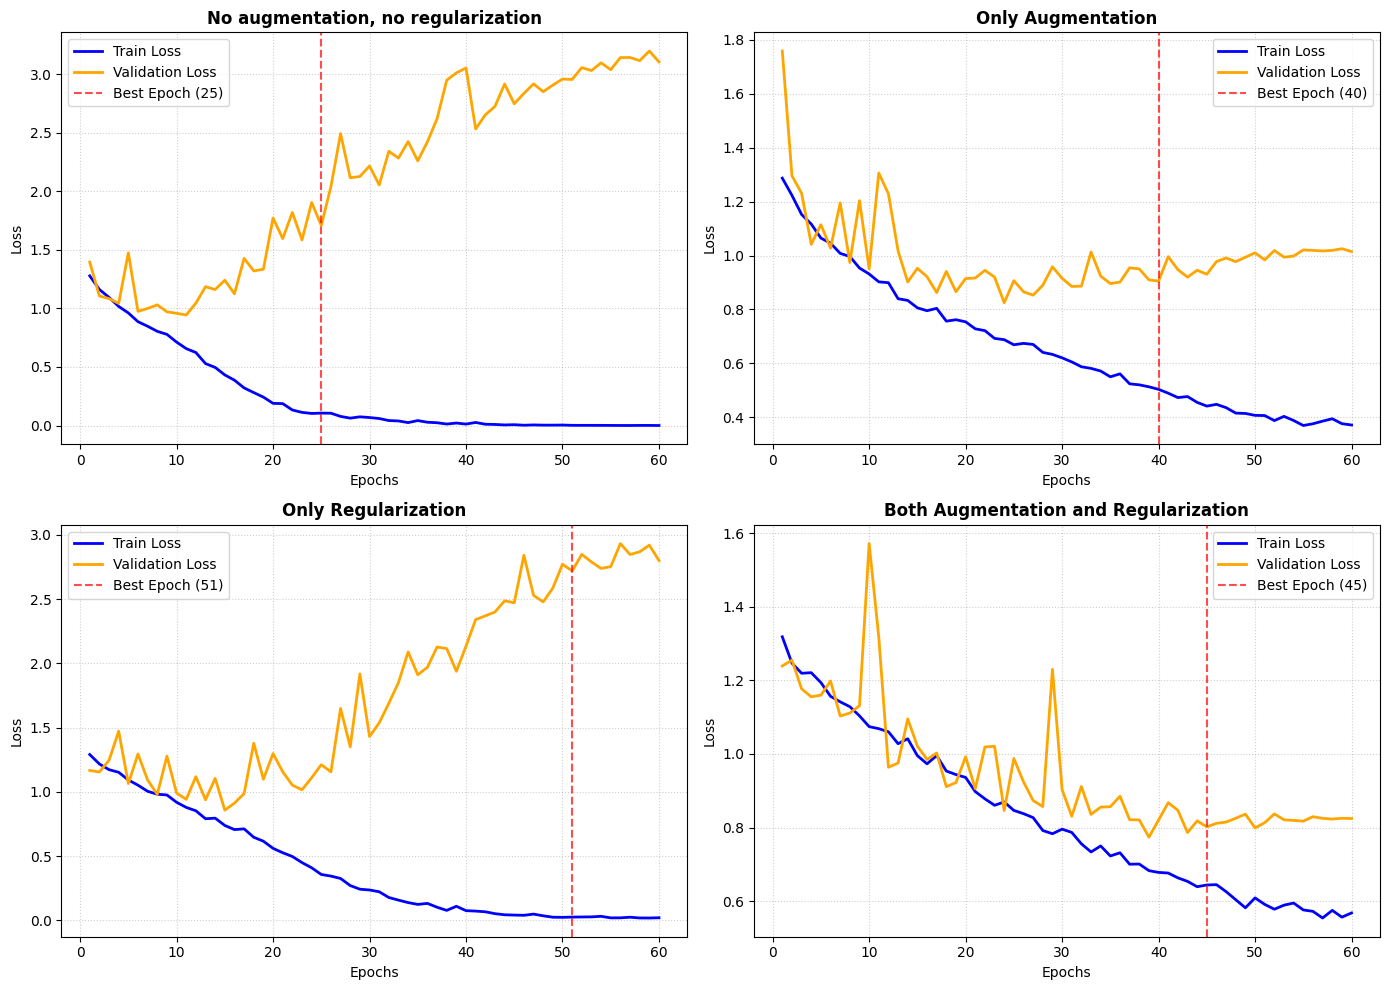


-------------------------------------------------------------------------------------
| Experiment configuration | Best epoch | Val F1 | Test F1 | Train-Val gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 25 | 0.6544 | 0.6538 | 1.6016 |
| Only Augmentation | 40 | 0.6862 | 0.7001 | 0.4015 |
| Only Regularization | 51 | 0.6801 | 0.6632 | 2.6942 |
| Both Augmentation and Regularization | 45 | 0.6850 | 0.7055 | 0.1581 |
-------------------------------------------------------------------------------------



In [47]:
from torch.utils.data import Dataset

class WikiArtAugmentedDataset(Dataset):
    def __init__(self, x_tensor, y_tensor, transform=None):
        self.x_tensor = x_tensor
        self.y_tensor = y_tensor
        self.transform = transform

    def __len__(self):
        return len(self.x_tensor)

    def __getitem__(self, idx):
        img = self.x_tensor[idx]
        label = self.y_tensor[idx]

        if self.transform:
            img_uint8 = (img * 255.0).to(torch.uint8)
            # apply transformations
            img = self.transform(img_uint8)
        return img, label

# transformations for augmentation
augmented_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ConvertImageDtype(torch.float32)
])

# augmented train datasets
augmented_train_dataset = WikiArtAugmentedDataset(x_train, y_train, transform=augmented_transforms)
plain_train_dataset = WikiArtAugmentedDataset(x_train, y_train, transform=None)

# val/test datasets (no transformation)
val_dataset_clean = WikiArtAugmentedDataset(x_val, y_val, transform=None)
test_dataset_clean = WikiArtAugmentedDataset(x_test, y_test, transform=None)

# replacing dataloaders
val_dataloader_clean  = DataLoader(val_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)
test_dataloader_clean = DataLoader(test_dataset_clean, batch_size=BATCH_SIZE, shuffle=False)

experiments = {
    "No augmentation, no regularization": {"aug": False, "reg": False, "dropout": 0.0, "wd": 0.0},
    "Only Augmentation": {"aug": True,  "reg": False, "dropout": 0.0, "wd": 0.0},
    "Only Regularization": {"aug": False, "reg": True,  "dropout": 0.3, "wd": 1e-4},
    "Both Augmentation and Regularization":     {"aug": True,  "reg": True, "dropout": 0.3, "wd": 1e-4}
}

NEW_EPOCHS = 60
experiment_results = {}
criterion = nn.CrossEntropyLoss()

for exp_name, config in experiments.items():
    print(f"\n>>> Running Experiment: {exp_name}")
    # selecting training dataset
    selected_train_dataset = augmented_train_dataset if config["aug"] else plain_train_dataset

    # reproducibility
    g = torch.Generator()
    g.manual_seed(SEED)

    current_train_loader = DataLoader(
        selected_train_dataset,
        batch_size=train_dataloader.batch_size,
        shuffle=True,
        generator=g,
        num_workers=train_dataloader.num_workers,
        pin_memory=train_dataloader.pin_memory
    )

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RegularizedBatchNormCNN(dropout_p=config["dropout"]).to(device)
    if exp_name == "No augmentation, no regularization":
        print(model)
        print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
        print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=config["wd"])
    scheduler = CosineAnnealingLR(optimizer, T_max=NEW_EPOCHS)

    train_losses, val_losses = [], []
    best_val_f1 = -1.0
    best_val_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    best_epoch = 0
    start_time = time.time()
    # training
    for epoch in range(NEW_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, current_train_loader, optimizer, criterion)
        val_loss, val_acc, val_f1, val_cm = evaluate(model, val_dataloader_clean, criterion)

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())
    end_time = time.time()

    # best model evaluation on test set
    model.load_state_dict(best_model_wts)
    test_loss, test_acc, test_f1, test_cm = evaluate(model, test_dataloader_clean, criterion)

    experiment_results[exp_name] = {
        "train_losses": train_losses,
        "val_losses": val_losses,
        "Best_Epoch": best_epoch,
        "Val_Acc": best_val_acc,
        "Val_F1": best_val_f1,
        "Test_Acc": test_acc,
        "Test_F1": test_f1
    }
    print(f"\"{exp_name}\" finished! Best Epoch: {best_epoch} | Test Acc: {test_acc*100:.2f}% | Test F1: {test_f1:.4f} | Training time: {end_time-start_time:.2f}s |")
print("\n")
print(f"Total number of parameters: {sum(p.numel() for p in model.parameters())}")

# train/val loss curves per experiment
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, (exp_name, results) in enumerate(experiment_results.items()):
    epochs_range = range(1, NEW_EPOCHS + 1)
    axes[i].plot(epochs_range, results["train_losses"], label='Train Loss', color='blue', lw=2)
    axes[i].plot(epochs_range, results["val_losses"], label='Validation Loss', color='orange', lw=2)
    axes[i].axvline(x=results["Best_Epoch"], color='red', linestyle='--', alpha=0.7, label=f'Best Epoch ({results["Best_Epoch"]})')

    axes[i].set_title(exp_name, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('Loss')
    axes[i].legend()
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print("\n" + "-"*85)
print("| Experiment configuration | Best epoch | Val F1 | Test F1 | Train-Val gap |")
print("| :--- | :---: | :---: | :---: | :---: |")
for exp_name, res in experiment_results.items():
    print(f"| {exp_name} | {res['Best_Epoch']} | {res['Val_F1']:.4f} | {res['Test_F1']:.4f} | {res['val_losses'][res['Best_Epoch']-1] - res['train_losses'][res['Best_Epoch']-1]:.4f} |")
print("-"*85 + "\n")

# Regularization and Augmentation Results

| Experiment configuration | Best Epoch | Validation F1 | Test F1 | Train-Validation Loss Gap |
| :--- | :---: | :---: | :---: | :---: |
| No augmentation, no regularization | 25 | 0.6544 | 0.6538 | 1.6016 |
| Data augmentation | 40 | 0.6862 | 0.7001 | 0.4015 |
| Weight decay and dropout | 51 | 0.6801 | 0.6632 | 2.6942 |
| Data augmentation and regularization | 45 | 0.6850 | 0.7055 | 0.1581 |

The combined augmentation and regularization setup produced both the smallest train-validation gap and the strongest test F1. The selected transformations preserve the visual identity of paintings: horizontal flips, small crops, and mild brightness or contrast changes are reasonable, while vertical flips, grayscale conversion, large hue shifts, and strong rotations can alter meaningful artistic cues.

# Transfer Learning with a Pre-trained ResNet18

In [48]:
import torchvision.models as models

def process_batch_for_resnet(images, device):
    # upscale from 32x32 to 224x224
    images_large = F.interpolate(images, size=224, mode='bilinear', align_corners=False)

    # ImageNet normalization (mean & std per channel)
    mean = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)
    images_norm = (images_large - mean) / std

    return images_norm

# new train function for resnet
def train_resnet_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # pre-processing before input into resnet
        images_processed = process_batch_for_resnet(images, device)

        optimizer.zero_grad()
        outputs = model(images_processed)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    return running_loss / total, correct / total

# new evaluate function for resnet
def evaluate_resnet(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # pre-processing before input into resnet
            images_processed = process_batch_for_resnet(images, device)

            outputs = model(images_processed)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    total = len(all_labels)
    loss = running_loss / total
    acc = sum([1 for p, l in zip(all_preds, all_labels) if p == l]) / total
    f1 = f1_score(all_labels, all_preds, average='macro')
    cm = confusion_matrix(all_labels, all_preds)

    return loss, acc, f1, cm

# reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

resnet18 = models.resnet18(weights="IMAGENET1K_V1")

# freeze all parameters
for p in resnet18.parameters():
    p.requires_grad = False

resnet18.fc = nn.Linear(512, 4)
resnet18 = resnet18.to(device)

print(resnet18)
print(f"Total parameters: {sum(p.numel() for p in resnet18.parameters()):,}")
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params:,}")

g = torch.Generator()
g.manual_seed(SEED)
resnet_train_dataloader = DataLoader(
    plain_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=g,
    num_workers=2,
    pin_memory=True,
)

optimizer = optim.Adam(resnet18.fc.parameters(), lr=0.001) # only the fc is trained
criterion = nn.CrossEntropyLoss()
RESNET_EPOCHS = 10
best_val_f1 = -1.0
best_model_wts = copy.deepcopy(resnet18.state_dict())

start_time = time.time()

for epoch in range(RESNET_EPOCHS):
    train_loss, train_acc = train_resnet_epoch(resnet18, resnet_train_dataloader, optimizer, criterion, device)
    val_loss, val_acc, val_f1, val_cm = evaluate_resnet(resnet18, val_dataloader_clean, criterion, device)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(resnet18.state_dict())

    print(f"Epoch {epoch+1:02d}/{RESNET_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val F1: {val_f1:.4f}")

end_time = time.time()
print(f"\nTraining complete in: {end_time - start_time:.2f}s.")

# best model evaluation on test set
resnet18.load_state_dict(best_model_wts)
test_loss, test_acc, test_f1, test_cm = evaluate_resnet(resnet18, test_dataloader_clean, criterion, device)

print("\n" + "-"*50)
print("RESULTS FROZEN RESNET18 (TEST SET)")
print("-"*50)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test F1 Macro: {test_f1:.4f}")
print("-"*50 + "\n")

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# Transfer Learning Results

| Model | Test Accuracy | Macro F1 | Trainable Parameters | Training Time |
| :--- | :---: | :---: | :---: | :---: |
| Feedforward baseline | 48.92% | 0.4883 | 397,604 | 23.42 s |
| Best custom CNN | 70.43% | 0.7055 | 1,066,788 | 198.31 s |
| Frozen ResNet18 with linear probe | 75.07% | 0.7493 | 2,052 | 50.65 s |

The frozen ResNet18 performed best despite training only its final linear layer. Its ImageNet features provide reusable low-level and mid-level visual representations, including edges, color contrasts, shapes, and textures. Upscaling the 32x32 inputs to 224x224 introduces artifacts, but the pre-trained representation still transfers effectively to this artistic domain.

>>> Extracting filters of 1st convolutional layer from both models...


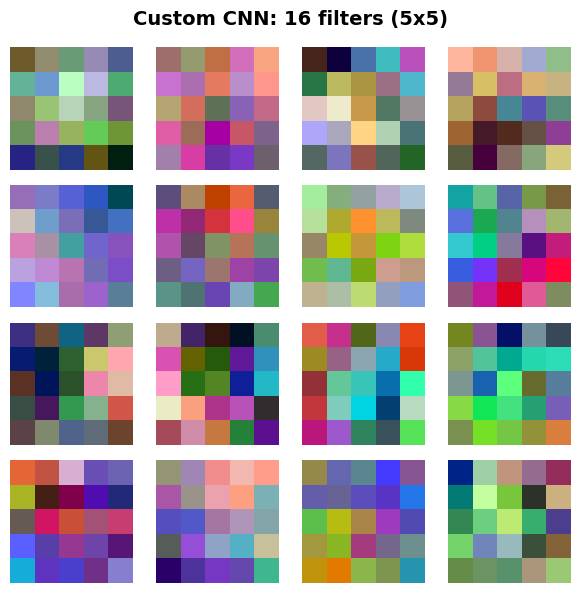

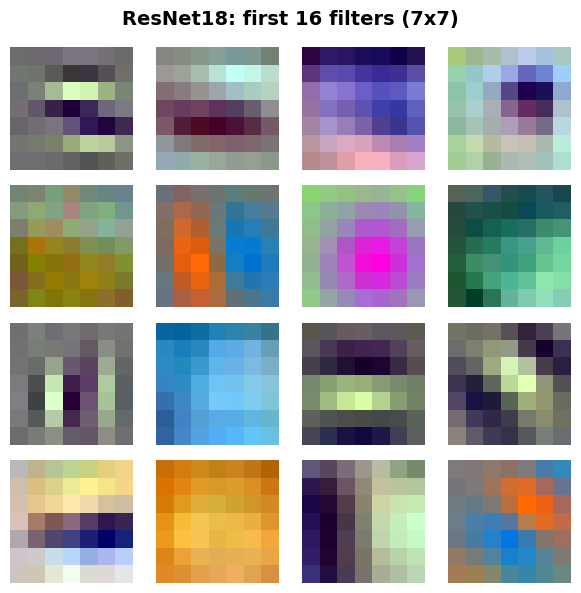


>>> Extracting activation maps (heatmaps) for one sample per class...

Class: Baroque



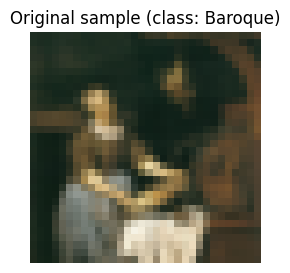

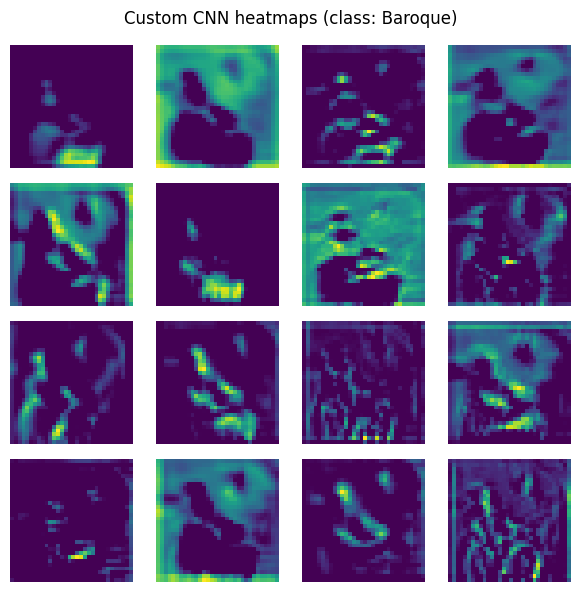

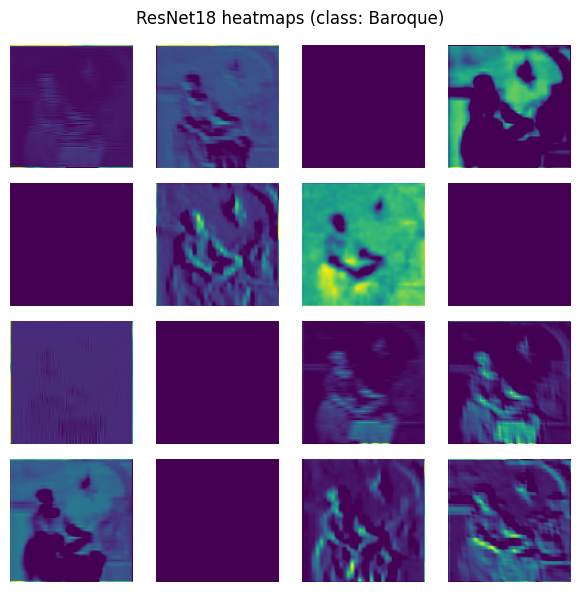




Class: Impressionism



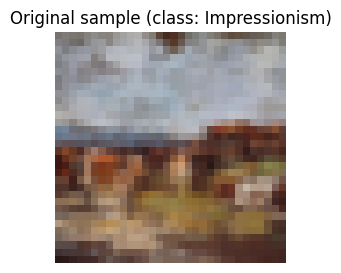

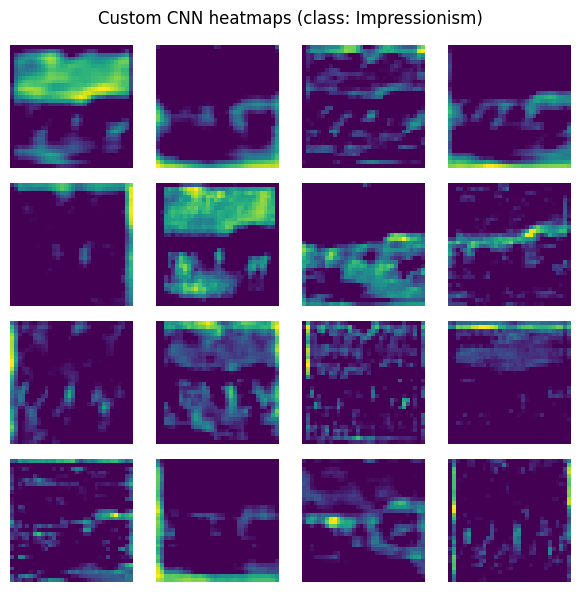

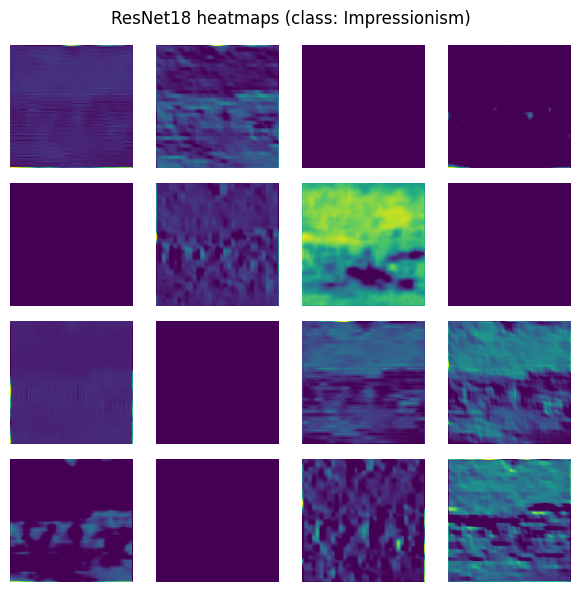




Class: Cubism



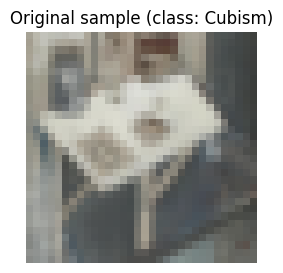

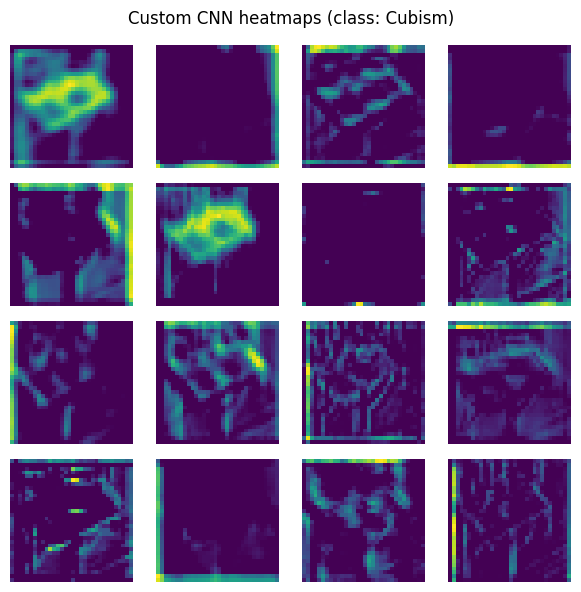

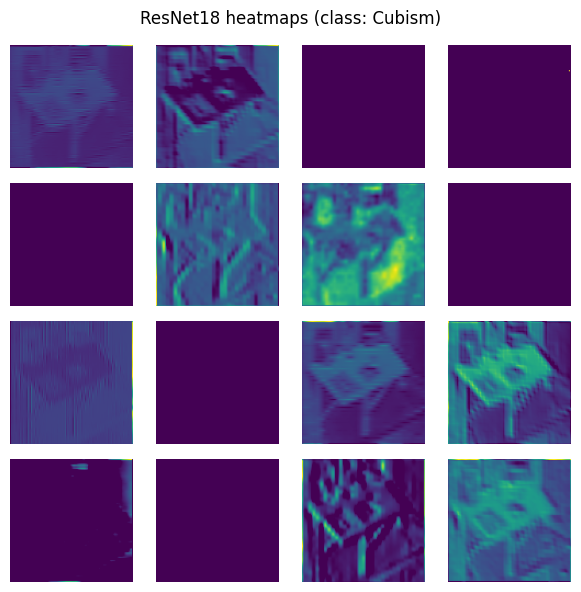




Class: Abstract Expressionism



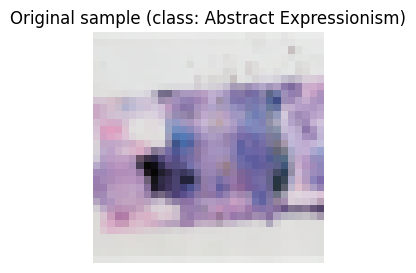

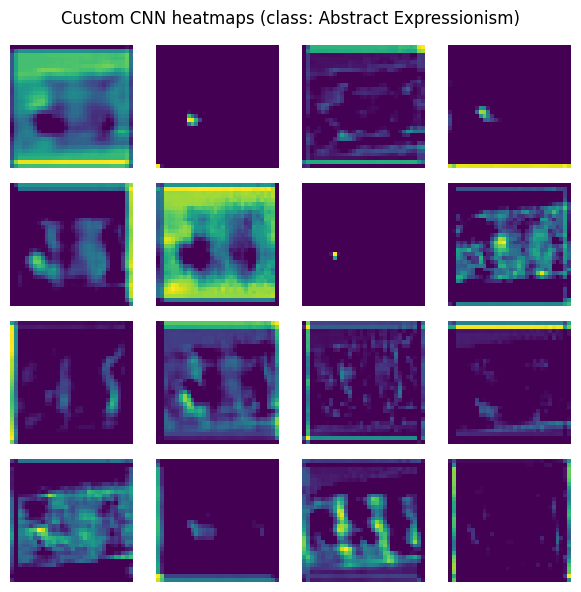

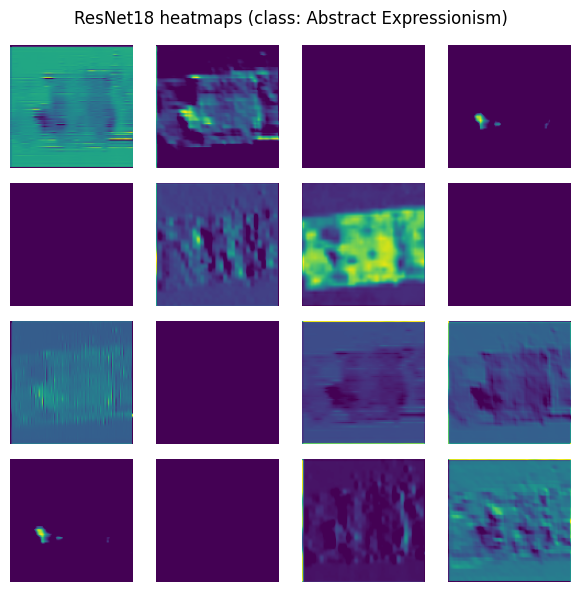

In [49]:
my_custom_cnn = model       # optimal cnn model from 3.2
my_resnet = resnet18        # optimal resnet18 from 4.1

my_custom_cnn.eval()
my_resnet.eval()

def plot_filters(weights, title):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, ax in enumerate(axes.flatten()):
        f = weights[i].detach().clone()

        # min-max normalization -> [0, 1]
        f_min, f_max = f.min(), f.max()
        f_norm = (f - f_min) / (f_max - f_min + 1e-8)

        # from Channel, Height, Width to Height, Width, Channels
        ax.imshow(f_norm.permute(1, 2, 0).numpy())
        ax.axis('off')

    plt.tight_layout()
    plt.show()

print(">>> Extracting filters of 1st convolutional layer from both models...")
# custom CNN
custom_filters = my_custom_cnn.conv1.weight.cpu()
plot_filters(custom_filters, "Custom CNN: 16 filters (5x5)")

# ResNet18
resnet_filters = my_resnet.conv1.weight.cpu()[:16]
plot_filters(resnet_filters, "ResNet18: first 16 filters (7x7)")


def get_custom_cnn_activations(net, img_tensor, device):
    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        x = net.conv1(x)
        x = net.bn1(x)
        x = net.relu(x)
    return x.cpu().squeeze(0)

def get_resnet_activations(net, img_tensor, device):
    with torch.no_grad():
        x = img_tensor.unsqueeze(0).to(device)
        x = process_batch_for_resnet(x, device)
        x = net.conv1(x)
        x = net.bn1(x)
        x = net.relu(x)
    return x.cpu().squeeze(0)[:16]

def plot_activations(activations, title):
    fig, axes = plt.subplots(4, 4, figsize=(6, 6))
    fig.suptitle(title, fontsize=12)

    for i, ax in enumerate(axes.flatten()):
        ax.imshow(activations[i].numpy(), cmap='viridis')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# random sample from each class of test set
random.seed(SEED)
class_samples = {}
indices = list(range(len(test_dataset_clean)))
random.shuffle(indices)

for idx in indices:
    img, label = test_dataset_clean[idx]
    lbl = int(label.item())
    if lbl not in class_samples:
        class_samples[lbl] = img
    if len(class_samples) == 4:
        break

print("\n>>> Extracting activation maps (heatmaps) for one sample per class...")
for lbl in sorted(class_samples.keys()):
    img = class_samples[lbl]

    print(f"\nClass: {class_names[lbl]}\n")

    # original sample
    plt.figure(figsize=(3, 3))
    plt.title(f"Original sample (class: {class_names[lbl]})")
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.axis('off')
    plt.show()

    # activations custom CNN
    acts_custom = get_custom_cnn_activations(my_custom_cnn, img, device)
    plot_activations(acts_custom, f"Custom CNN heatmaps (class: {class_names[lbl]})")

    # activations ResNet18
    acts_resnet = get_resnet_activations(my_resnet, img, device)
    plot_activations(acts_resnet, f"ResNet18 heatmaps (class: {class_names[lbl]})")
    print("\n")

In [50]:
global_end_time = time.time()
print(f"Total runtime: {int((global_end_time-global_start_time) // 60)}m {(global_end_time-global_start_time) % 60:.2f}s")

Total runtime: 22m 27.74s


# Learned Visual Representations

The pre-trained ResNet18 filters are typically clearer, more structured and more interpretable than the filters learned by the custom CNN from the small 32x32 dataset. They often resemble edge detectors, color blobs, and light-dark contrast filters, reflecting the broad visual statistics learned from ImageNet. The custom CNN can still learn useful cues such as contrast for Baroque, geometric edges for Cubism, and color or texture patterns for Impressionism and Abstract Expressionism, but its filters are generally noisier. Compared with the flat-pixel FFN weights, convolutional filters preserve local spatial structure and can detect the same visual pattern at different image locations.